In [ ]:
import jax.numpy as jnp
import jax

# Now plotting the things
import matplotlib.pyplot as plt
from mGST.utility_functions_comparisons import kraus_tensor_to_mgst, povm_psd_to_mgst, state_psd_to_mgst
from mGST.low_level_jit import contract_mps_general_povm, contract_mps_abstract_povm_coherent
from mGST.visualization import plot_wall_time

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [2]:
key = jax.random.PRNGKey(42)
def generate_random_instance(num_gates:int, num_qubits:int, rank_kraus:int, povm_rank:int = None, state_rank:int = None):
    dim = 2**num_qubits
    if povm_rank is None:
        povm_rank = dim
    if state_rank is None:
        state_rank = dim
        
    # Complex random tensors
    povm_rnd_tensor =  jax.random.uniform(key, shape=(1, povm_rank, dim)) + 1j * jax.random.uniform(key, shape=(1, povm_rank, dim)) # (num_povm, rank_povm, dim)
    kraus_rnd_tensor = jax.random.uniform(key, shape=(num_gates, rank_kraus, dim, dim)) + 1j * jax.random.uniform(key, shape=(num_gates, rank_kraus, dim, dim)) # (num_gates, kraus_rank, dim_out, dim_in)
    state_rnd_tensor = jax.random.uniform(key, shape=(dim, state_rank)) + 1j * jax.random.uniform(key, shape=(dim, state_rank)) # (dim, rank_state)
    gates_sequences_rnd = jax.random.randint(key, shape=(num_gates, ), minval=0, maxval=num_gates)
    return {"kraus_tensor": kraus_rnd_tensor, "povm_psd": povm_rnd_tensor, "state_psd": state_rnd_tensor, "gates_indices": gates_sequences_rnd}

def contract(X, j_vec):
    """Contract a sequence of matrices in the given order.
    
    Implementation from mGST.low_level_jit without the j_vec processing
    """
    res = jnp.eye(X[0].shape[0])
    res = res.astype(jnp.complex128)
    for j in j_vec:
        res = res.dot(X[j])
    return res

def contract_naive(kraus_tensor, povm_psd, state_psd, gates_indices):
    """
    Contraction path that creates first a big tensor for the gates and then contracts it with the state and povm.
    
    It is expected that this cost function scales as O((2^N)^8).
    """
    state_rnd_vect = state_psd_to_mgst(state_psd=state_psd)
    povm_rnd_vect = povm_psd_to_mgst(povm_psd=povm_psd)[0] # we take the first one since we only have one povm element
    superop = kraus_tensor_to_mgst(kraus_tensor=kraus_tensor)
    full_gates_superop = contract(superop, gates_indices)
    return povm_rnd_vect.conj() @ full_gates_superop @ state_rnd_vect

INFO:2026-02-19 17:38:33,032:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-02-19 17:38:33,032 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-02-19 17:38:33,035:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

# Data generation
* number of gates = 5
* kraus rank = 4
* state rank = povm rank = dim = 2^num_qubits

In [3]:
num_gates = 5
rank_kraus = 1

In [4]:
all_num_qubits = jnp.arange(1, 10)

all_tensors = []

for qubits in all_num_qubits:

    tensors = generate_random_instance(num_gates, qubits, rank_kraus)
    all_tensors.append(tensors)

    if qubits <= 6: # for more than 6 qubits the naive contraction takes too long
        cost_mgst = contract_naive(**tensors)

        cost_mps = contract_mps_general_povm(**tensors)

        print(jnp.allclose(cost_mgst, cost_mps))

True
True
True
True
True
True


In [12]:
# testing for the coherent one if they are all the same with the general mps cost
for tensors in all_tensors:
    cost_mps_general = contract_mps_general_povm(**tensors)
    cost_mps_coherent = contract_mps_abstract_povm_coherent(**tensors)
    print(jnp.allclose(cost_mps_general, cost_mps_coherent))

True
True
True
True
True
True
True
True
True


In [7]:
all_tensors[0]["kraus_tensor"].shape

(5, 1, 2, 2)

# Timing

In [5]:
timing_cost_1q_naive = %timeit -o contract_naive(**all_tensors[0])
timing_cost_2q_naive = %timeit -o contract_naive(**all_tensors[1])
timing_cost_3q_naive = %timeit -o contract_naive(**all_tensors[2])
timing_cost_4q_naive = %timeit -o contract_naive(**all_tensors[3])
timing_cost_5q_naive = %timeit -o contract_naive(**all_tensors[4])

1.17 ms ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.27 ms ± 4.78 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.49 ms ± 4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
7.74 ms ± 435 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
264 ms ± 3.89 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
timing_cost_1q_mps = %timeit -o contract_mps_general_povm(**all_tensors[0])
timing_cost_2q_mps = %timeit -o contract_mps_general_povm(**all_tensors[1])
timing_cost_3q_mps = %timeit -o contract_mps_general_povm(**all_tensors[2])
timing_cost_4q_mps = %timeit -o contract_mps_general_povm(**all_tensors[3])
timing_cost_5q_mps = %timeit -o contract_mps_general_povm(**all_tensors[4])

1.74 ms ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.8 ms ± 50.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.89 ms ± 43.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.92 ms ± 26.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.19 ms ± 454 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
timing_cost_6q_mps = %timeit -o contract_mps_general_povm(**all_tensors[5])
timing_cost_7q_mps = %timeit -o contract_mps_general_povm(**all_tensors[6])
timing_cost_8q_mps = %timeit -o contract_mps_general_povm(**all_tensors[7])
timing_cost_9q_mps = %timeit -o contract_mps_general_povm(**all_tensors[8])

2.09 ms ± 10.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3.91 ms ± 190 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
16.3 ms ± 269 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
93 ms ± 3.35 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
timing_cost_1q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[0])
timing_cost_2q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[1])
timing_cost_3q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[2])
timing_cost_4q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[3])
timing_cost_5q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[4])

1.05 ms ± 17.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.05 ms ± 6.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.1 ms ± 6.94 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.09 ms ± 3.41 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.14 ms ± 6.15 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [17]:
timing_cost_6q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[5])
timing_cost_7q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[6])
timing_cost_8q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[7])
timing_cost_9q_mps_coherent = %timeit -o contract_mps_abstract_povm_coherent(**all_tensors[8])

1.26 ms ± 16.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.01 ms ± 48 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
8.11 ms ± 16.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
45.2 ms ± 210 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Gathering data

In [25]:
timings_naive = [timing_cost_1q_naive, timing_cost_2q_naive, timing_cost_3q_naive, timing_cost_4q_naive, timing_cost_5q_naive]
timings_mps = [timing_cost_1q_mps, timing_cost_2q_mps, timing_cost_3q_mps, timing_cost_4q_mps, timing_cost_5q_mps, timing_cost_6q_mps, timing_cost_7q_mps, timing_cost_8q_mps, timing_cost_9q_mps]
timings_mps_coherent = [timing_cost_1q_mps_coherent, timing_cost_2q_mps_coherent, timing_cost_3q_mps_coherent, timing_cost_4q_mps_coherent, timing_cost_5q_mps_coherent, timing_cost_6q_mps_coherent, timing_cost_7q_mps_coherent, timing_cost_8q_mps_coherent, timing_cost_9q_mps_coherent]

tuples_naive = [(time.average, time.stdev) for time in timings_naive]
tuples_mps = [(time.average, time.stdev) for time in timings_mps]
tuples_mps_coherent = [(time.average, time.stdev) for time in timings_mps_coherent]

cost_fn_times = {
    r"Brieger et al.": tuples_naive,
    r"MPS (incoherent)": tuples_mps,
    r"MPS (coherent)": tuples_mps_coherent
}

# Plotting

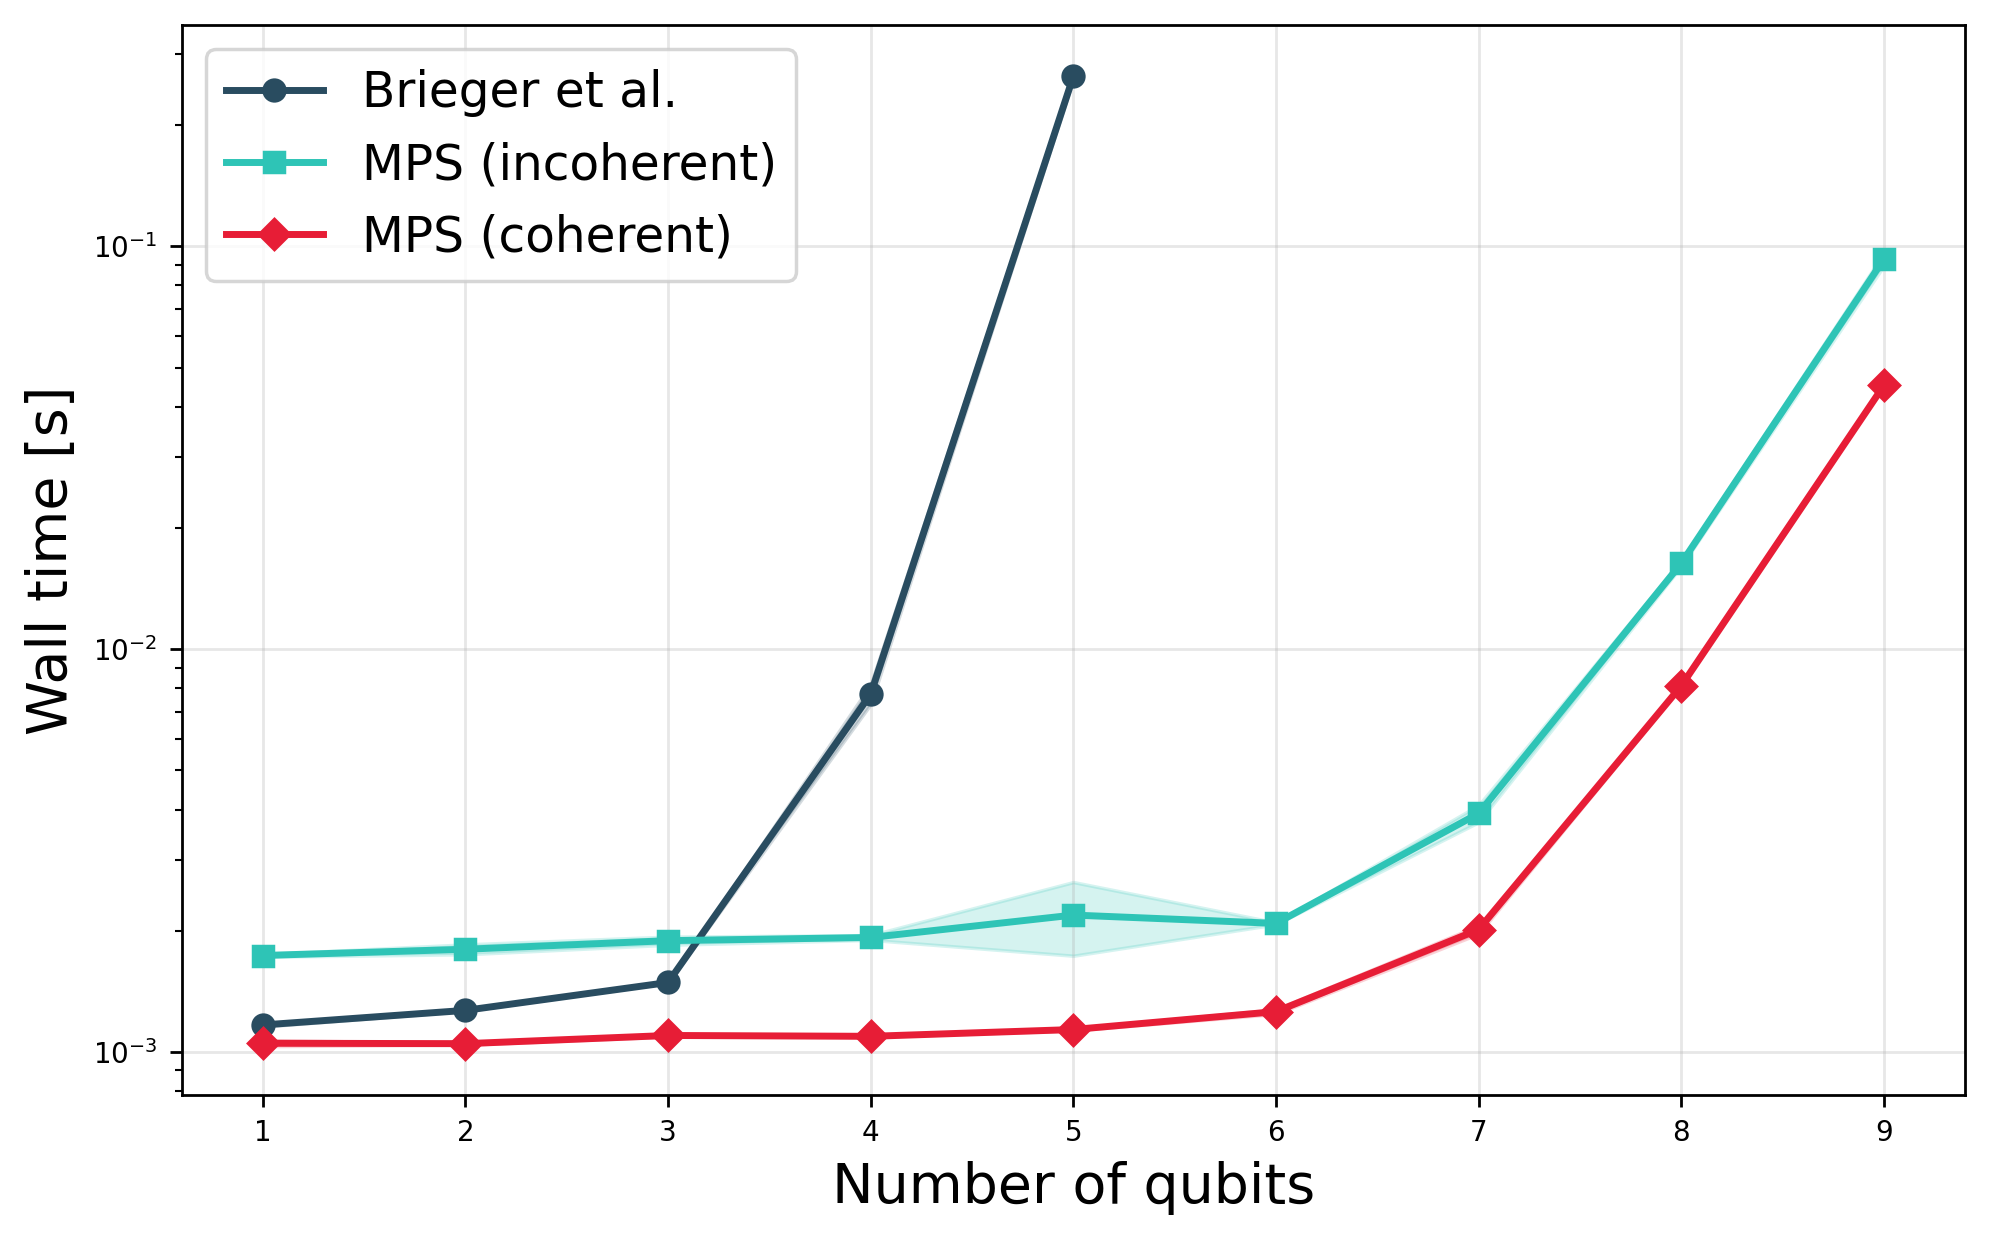

In [33]:
plot_wall_time(time_data=cost_fn_times, x_values=all_num_qubits, logscale="y", title=None, different_lengths_allowed=True, label_fontsize=16, legend_fontsize=14, legend_loc="upper left")

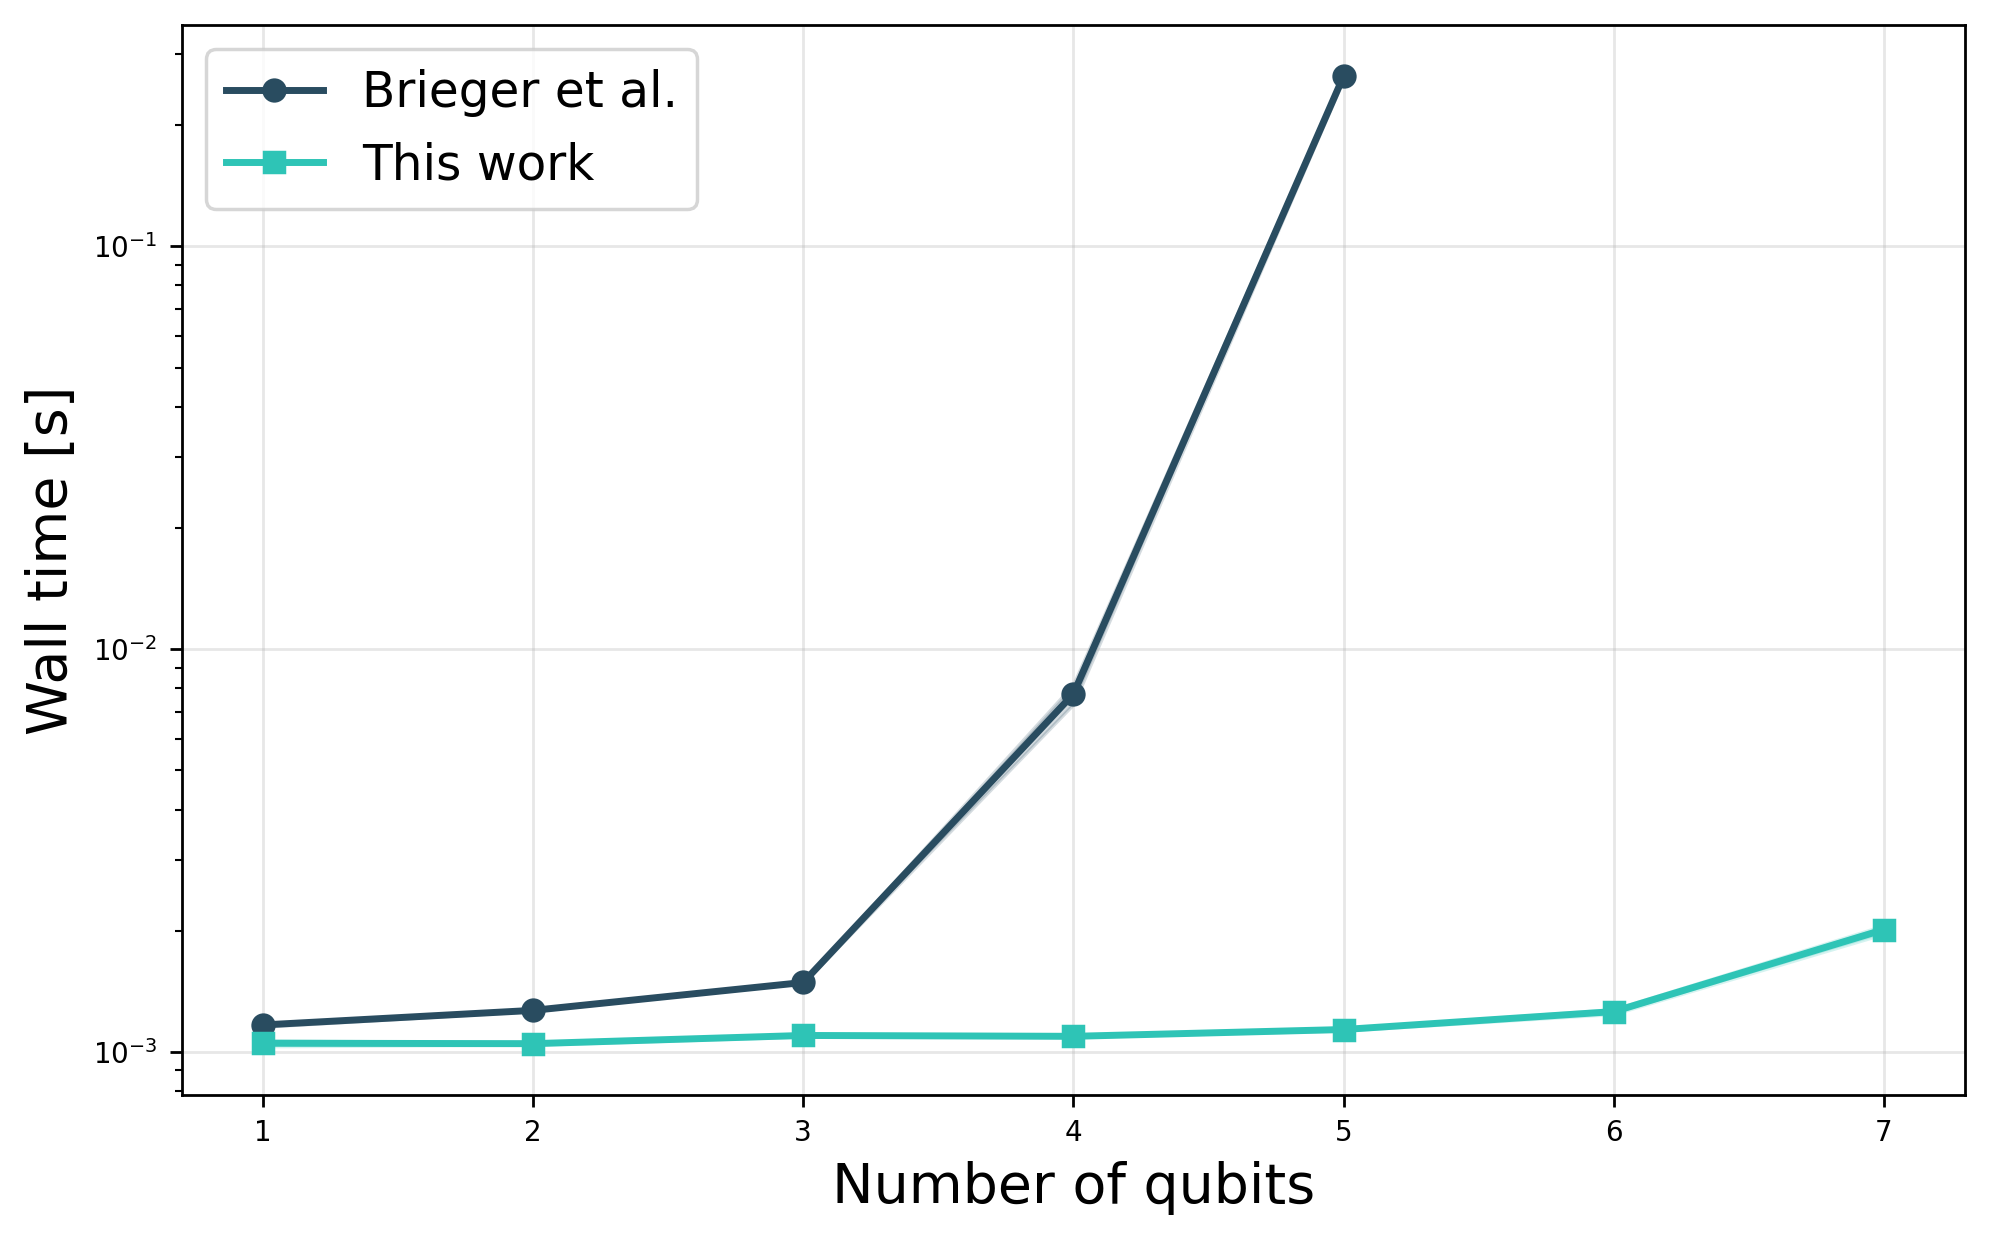

In [36]:
cost_fn_times_intro = {
    r"Brieger et al.": tuples_naive,
    r"This work": tuples_mps_coherent[:7]
}
plot_wall_time(time_data=cost_fn_times_intro, x_values=all_num_qubits, logscale="y", title=None, different_lengths_allowed=True, label_fontsize=16, legend_fontsize=14, legend_loc="upper left")

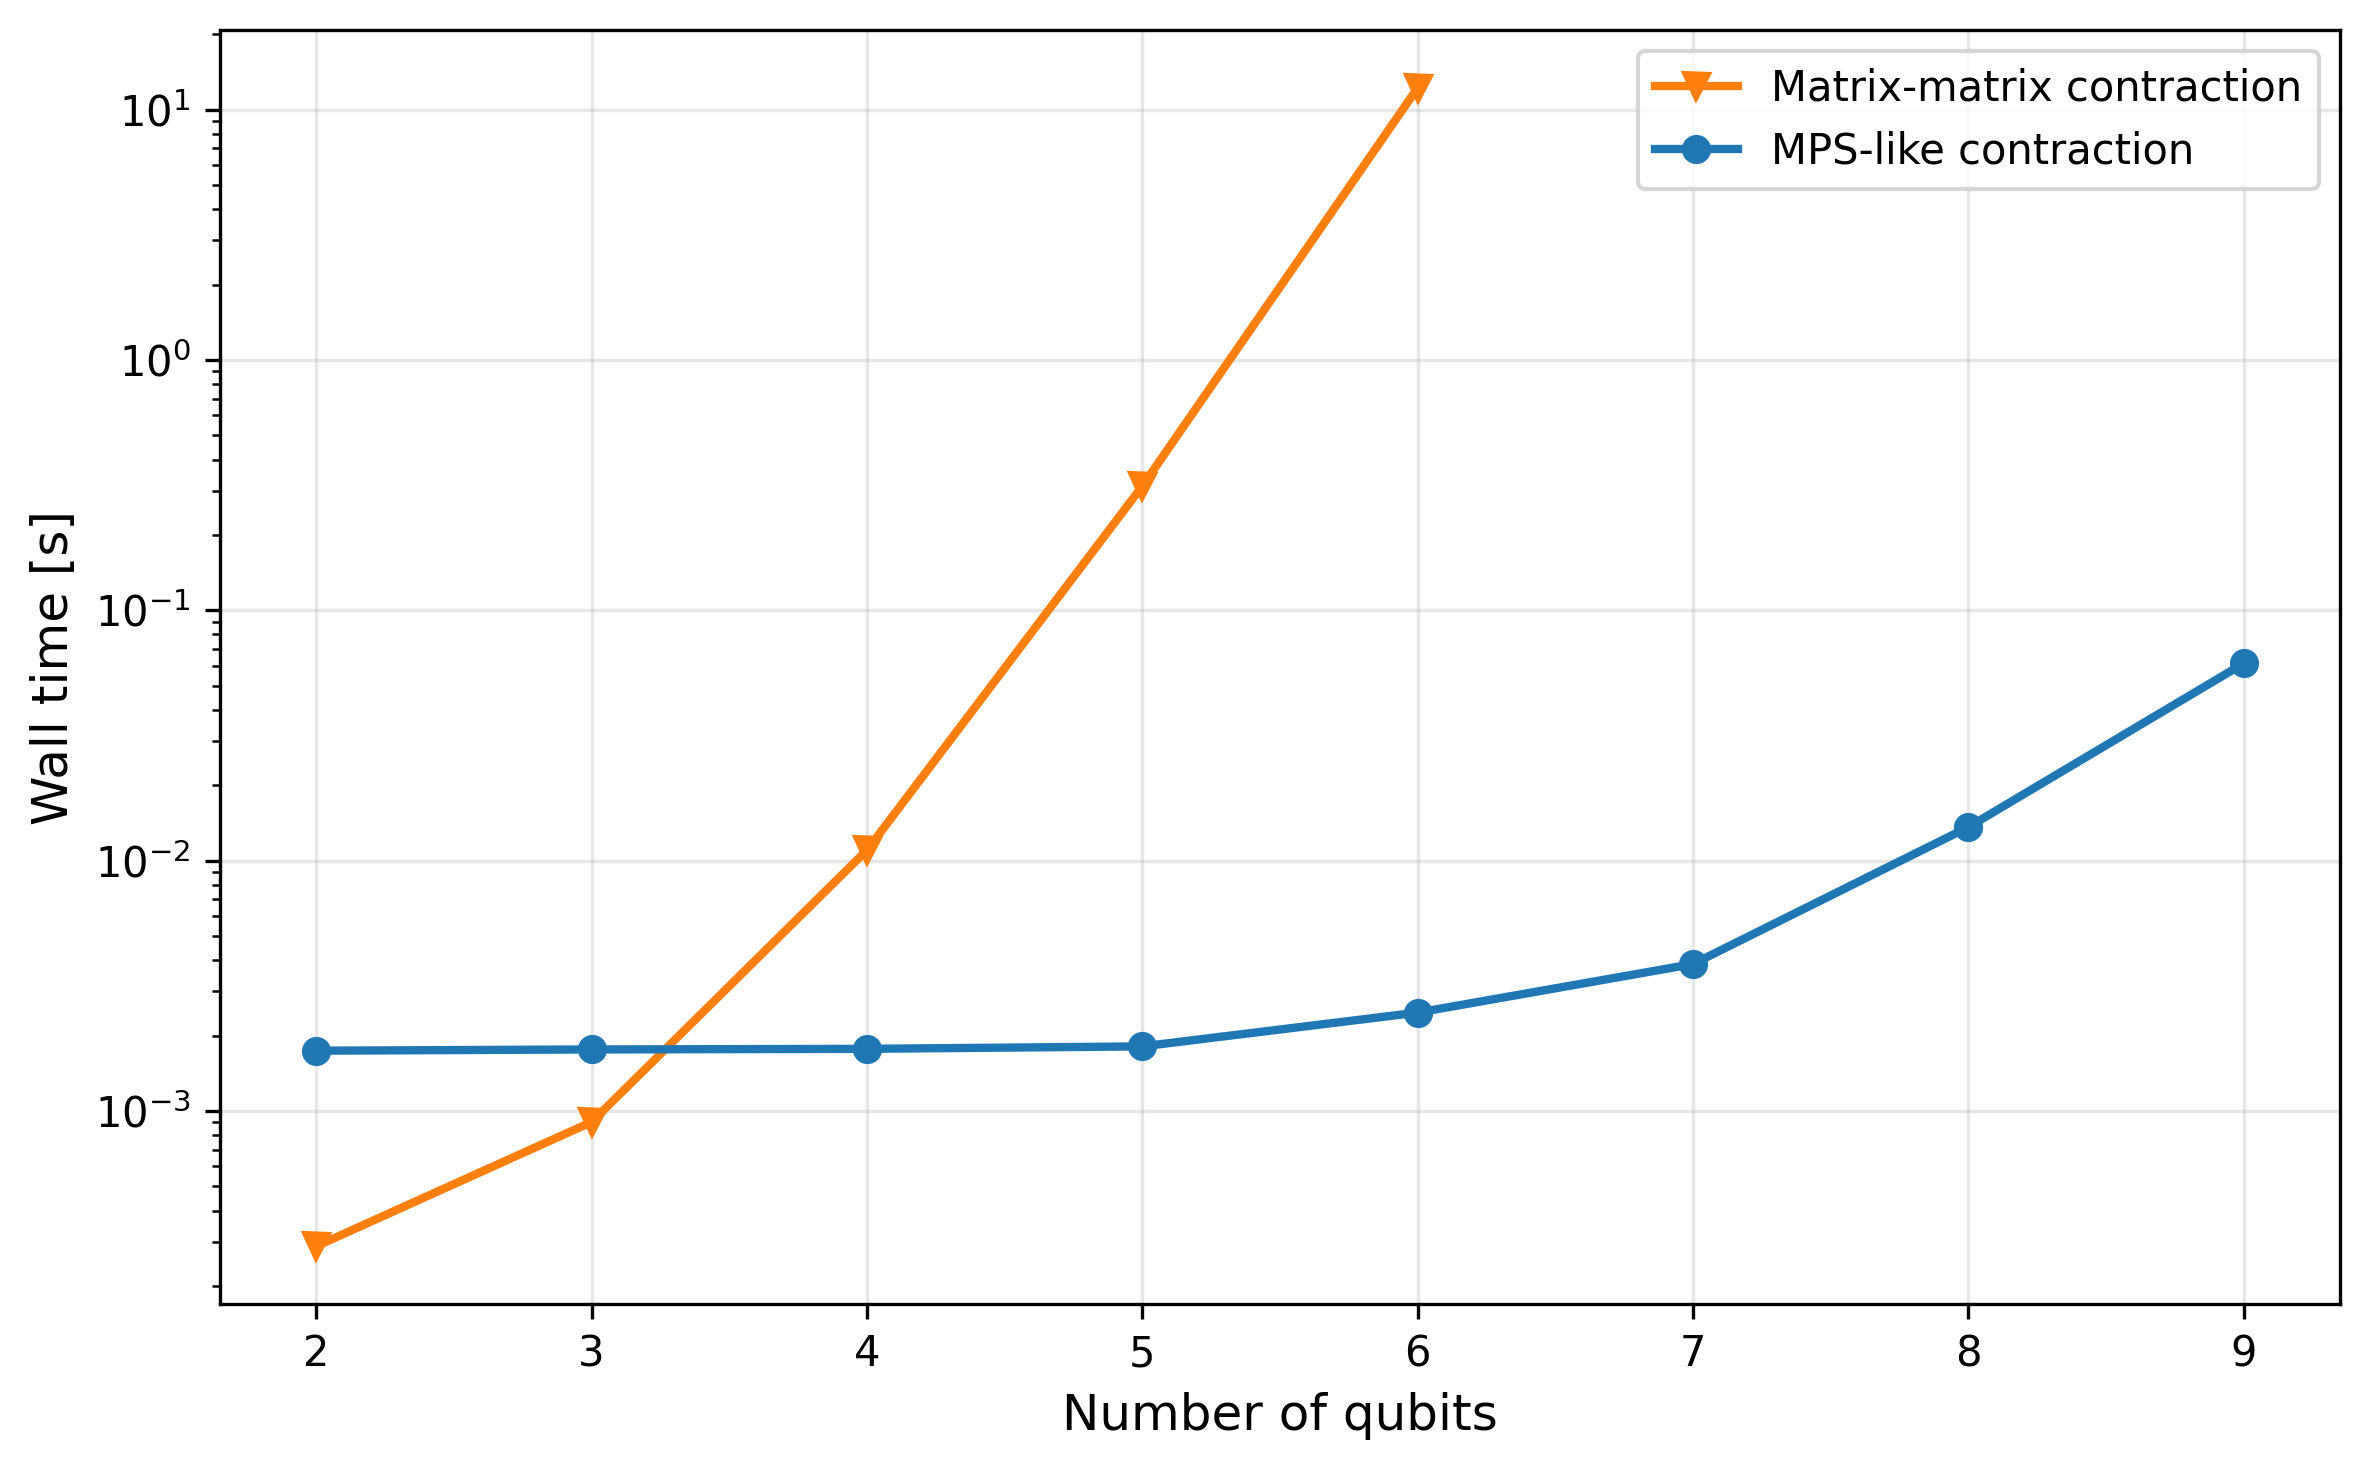

In [5]:
# Create the plot
plt.figure(figsize=(8, 5), dpi=300)

max_num_qubits = 6

times_naive = jnp.array([288e-6, 903e-6, 11e-3, 313e-3, 12.2])
times_mps_opt_path= jnp.array([1.74, 1.76, 1.77, 1.81, 2.47, 3.86, 13.6, 61.3])/1000


plt.semilogy(range(2, max_num_qubits+1), times_naive, label="Matrix-matrix contraction", color="#ff7f0e", linestyle="-", marker="v", linewidth=2, markersize=6)
plt.semilogy(range(2, max_num_qubits+4), times_mps_opt_path, label="MPS-like contraction", color="#1f77b4", linestyle="-", marker="o", linewidth=2, markersize=6)


# Add labels, legend, and grid
plt.xlabel("Number of qubits", fontsize=12)
plt.ylabel("Wall time [s]", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Cost fn vs Gradient vs Hvp